C:\Users\USER\anaconda3\envs\py310\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (6.0.0.post1)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(



================ MODEL: CNN ================

------ SEED 42 ------

[Model=CNN | Seed=42 | Round=1]
 Client 0 → Loss=0.0540, Acc=0.9870, Time=8.62s, N=20244
 Client 1 → Loss=0.0586, Acc=0.9858, Time=4.76s, N=20244
 Client 2 → Loss=0.0555, Acc=0.9869, Time=4.59s, N=20243
 Client 3 → Loss=0.0558, Acc=0.9866, Time=4.65s, N=20243
 >>> GLOBAL (centralized test) → Loss=0.0332, Acc=0.9918

[Model=CNN | Seed=42 | Round=2]
 Client 0 → Loss=0.0305, Acc=0.9917, Time=4.49s, N=20244
 Client 1 → Loss=0.0350, Acc=0.9914, Time=4.59s, N=20244
 Client 2 → Loss=0.0280, Acc=0.9923, Time=4.56s, N=20243
 Client 3 → Loss=0.0300, Acc=0.9923, Time=4.63s, N=20243
 >>> GLOBAL (centralized test) → Loss=0.0136, Acc=0.9946

[Model=CNN | Seed=42 | Round=3]
 Client 0 → Loss=0.0196, Acc=0.9942, Time=4.63s, N=20244
 Client 1 → Loss=0.0236, Acc=0.9935, Time=4.59s, N=20244
 Client 2 → Loss=0.0187, Acc=0.9943, Time=4.49s, N=20243
 Client 3 → Loss=0.0211, Acc=0.9939, Time=4.56s, N=20243
 >>> GLOBAL (centralized test) → L

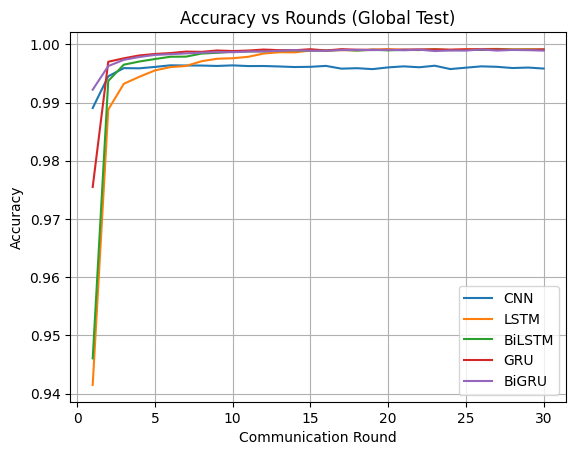

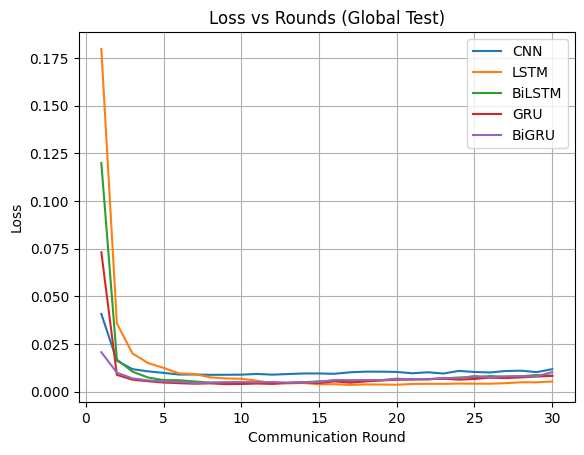

In [1]:
import numpy as np, pandas as pd, tensorflow as tf, random, time, os
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import *

from scipy.stats import ttest_rel, chi2, binom
from itertools import combinations

# ================= CONFIG =================
LR=0.001; ROUNDS=30; LOCAL_EPOCHS=2; BATCH=16
CLIENTS=4; SEEDS=[42,3,7,72,82]
MODELS=["CNN","LSTM","BiLSTM","GRU","BiGRU"]
CLIENT_TEST_SIZE=0.2   # local train/test split ratio inside each client
MODEL_SAVE_DIR="saved_models"
os.makedirs(MODEL_SAVE_DIR,exist_ok=True)

# ================= LOAD =================
df=pd.read_csv("url_features_extracted1(100K).csv")

# remove text columns like .txt
for col in df.columns:
    if df[col].dtype==object and df[col].astype(str).str.contains(".txt",na=False).any():
        df.drop(columns=[col],inplace=True)

df=df.fillna("unknown")

for col in df.columns:
    if df[col].dtype==object:
        df[col]=LabelEncoder().fit_transform(df[col].astype(str))

X=df.drop("ClassLabel",axis=1).values
y=df["ClassLabel"].values

X=StandardScaler().fit_transform(X)

# NOTE: no upfront global train_test_split anymore.
# IID partitioning is applied to the WHOLE dataset per seed below,
# then each client locally splits its own IID shard into train/test.

# ================= HELPERS =================
def set_seed(s):
    random.seed(s); np.random.seed(s); tf.random.set_seed(s)

def iid_partition(X,y,K):
    # IID partition: each class shuffled and split evenly across clients
    idx=np.arange(len(y))
    clients=[[] for _ in range(K)]
    for c in np.unique(y):
        c_idx=idx[y==c]; np.random.shuffle(c_idx)
        split=np.array_split(c_idx,K)
        for i in range(K): clients[i].extend(split[i])
    return [(X[c],y[c]) for c in clients]

def format_xy(Xc,model_name):
    return Xc.reshape(len(Xc),-1,1)

def fedavg(global_model,locals,sizes):
    w=[m.get_weights() for m in locals]
    new=[np.average(x,axis=0,weights=sizes) for x in zip(*w)]
    global_model.set_weights(new)

def model_size(model):
    model.save("tmp.h5", include_optimizer=False)
    size=os.path.getsize("tmp.h5")/(1024*1024)
    os.remove("tmp.h5")
    return size

def stats(x,metric):
    x=np.asarray(x,dtype=float)
    x=x[~np.isnan(x)]
    if len(x)==0:
        return np.nan,np.nan,np.nan,np.nan
    mean=np.mean(x); sd=np.std(x)
    ci=1.96*sd/np.sqrt(len(x))
    low,high=mean-ci,mean+ci
    if metric in ["Accuracy","Precision","Recall","F1","AUC","Specificity"]:
        low=max(0,low); high=min(1,high)
    if metric=="MCC":
        low=max(-1,low); high=min(1,high)
    return mean,sd,low,high

def mcnemar_test(y_true_a,y_pred_a,y_true_b,y_pred_b):
    """McNemar's test between two classifiers evaluated on the SAME samples.
    Uses only the discordant pairs (one right, one wrong). Exact binomial
    for small discordant counts (n<25), continuity-corrected chi-square
    otherwise."""
    y_true_a=np.asarray(y_true_a).flatten()
    y_true_b=np.asarray(y_true_b).flatten()
    assert len(y_true_a)==len(y_true_b), "test sets must be the same size"
    assert np.array_equal(y_true_a,y_true_b), "test sets must match (same seed/instances)"

    correct_a=(np.asarray(y_pred_a).flatten()==y_true_a)
    correct_b=(np.asarray(y_pred_b).flatten()==y_true_b)

    n01=int(np.sum(correct_a & ~correct_b))   # A correct, B wrong
    n10=int(np.sum(~correct_a & correct_b))   # A wrong, B correct
    n=n01+n10

    if n==0:
        return np.nan,1.0,n01,n10
    if n<25:
        p=2*min(binom.cdf(min(n01,n10),n,0.5),0.5)   # exact two-sided binomial
        p=min(p,1.0)
        stat=np.nan
    else:
        stat=((abs(n01-n10)-1)**2)/n                  # continuity-corrected chi-square
        p=1-chi2.cdf(stat,1)
    return stat,p,n01,n10

# ================= MODELS =================
def build(name,shape=None,dim=None):
    if name=="CNN":
        m=Sequential([
            Input(shape),
            Conv1D(64,3,activation="relu"),
            Dropout(0.5),
            Conv1D(32,3,activation="relu"),
            GlobalMaxPooling1D(),
            Dense(32,activation="relu"),
            Dropout(0.5),
            Dense(1,activation="sigmoid")
        ])

    elif name=="LSTM":
        m=Sequential([
            Input(shape),
            LSTM(128,return_sequences=True),
            Dropout(0.5),
            LSTM(64),
            Dropout(0.5),
            Dense(1,activation="sigmoid")
        ])

    elif name=="BiLSTM":
        m=Sequential([
            Input(shape),
            Bidirectional(LSTM(128,return_sequences=True)),
            Dropout(0.5),
            Bidirectional(LSTM(64)),
            Dropout(0.5),
            Dense(1,activation="sigmoid")
        ])

    elif name=="GRU":
        m=Sequential([
            Input(shape),
            GRU(128,return_sequences=True),
            Dropout(0.5),
            GRU(64),
            Dropout(0.5),
            Dense(1,activation="sigmoid")
        ])

    elif name=="BiGRU":
        m=Sequential([
            Input(shape),
            Bidirectional(GRU(128,return_sequences=True)),
            Dropout(0.5),
            Bidirectional(GRU(64)),
            Dropout(0.5),
            Dense(1,activation="sigmoid")
        ])

    m.compile(optimizer=Adam(LR),loss="binary_crossentropy",metrics=["accuracy"])
    return m

# ================= STORAGE =================
rows=[]          # global (union-of-clients) test metrics, per (model, seed)
client_rows=[]   # per-client local test metrics, per (model, seed, client)
results_round={m:{"acc":[],"loss":[],"cm":[]} for m in MODELS}

# per-instance predictions, needed for McNemar's test
y_preds={}        # (model, seed) -> y_pred array (0/1), aligned to y_trues[seed]
y_trues={}        # seed -> y_test_global array (0/1) -- same across all models for a given seed

# ================= TRAIN =================
for model_name in MODELS:
    print(f"\n================ MODEL: {model_name} ================")

    for seed in SEEDS:
        print(f"\n------ SEED {seed} ------")
        set_seed(seed)

        # ---- IID partition of the WHOLE dataset across clients ----
        client_full=iid_partition(X,y,CLIENTS)

        # ---- Each client locally splits its own shard into train/test ----
        client_train,client_test=[],[]
        for cid,(Xc,yc) in enumerate(client_full):
            try:
                Xc_tr,Xc_te,yc_tr,yc_te=train_test_split(
                    Xc,yc,test_size=CLIENT_TEST_SIZE,stratify=yc,random_state=seed
                )
            except ValueError:
                # fallback if a client shard doesn't have enough of a class to stratify
                Xc_tr,Xc_te,yc_tr,yc_te=train_test_split(
                    Xc,yc,test_size=CLIENT_TEST_SIZE,random_state=seed
                )
            client_train.append((Xc_tr,yc_tr))
            client_test.append((Xc_te,yc_te))

        # ---- Global (centralized) test set = union of all clients' local test shards ----
        X_test_global=np.concatenate([Xc for Xc,_ in client_test],axis=0)
        y_test_global=np.concatenate([yc for _,yc in client_test],axis=0)

        create=lambda:build(model_name,shape=(X.shape[1],1))

        fmt=lambda Xc: format_xy(Xc,model_name)

        global_model=create()

        acc_hist,loss_hist=[],[]
        comm=0
        total_train_time=0.0

        for r in range(ROUNDS):
            print(f"\n[Model={model_name} | Seed={seed} | Round={r+1}]")

            locals_=[]; sizes=[]

            for cid,(Xc,yc) in enumerate(client_train):
                m=create()
                m.set_weights(global_model.get_weights())

                t0=time.time()
                history=m.fit(fmt(Xc),yc,epochs=LOCAL_EPOCHS,batch_size=BATCH,verbose=0)
                t1=time.time()
                total_train_time+=(t1-t0)

                train_loss=history.history["loss"][-1]
                train_acc=history.history["accuracy"][-1]

                print(f" Client {cid} → Loss={train_loss:.4f}, Acc={train_acc:.4f}, Time={t1-t0:.2f}s, N={len(yc)}")

                locals_.append(m); sizes.append(len(yc))

            fedavg(global_model,locals_,sizes)

            loss,acc=global_model.evaluate(fmt(X_test_global),y_test_global,verbose=0)

            print(f" >>> GLOBAL (centralized test) → Loss={loss:.4f}, Acc={acc:.4f}")

            acc_hist.append(acc); loss_hist.append(loss)

            # bytes per weight (float32=4 bytes), sent down to each client AND back up from each client
            weight_bytes=sum([w.size for w in global_model.get_weights()])*4
            comm+=weight_bytes*CLIENTS*2

        # ================= FINAL GLOBAL TEST METRICS =================
        t0=time.time()
        y_prob=global_model.predict(fmt(X_test_global),verbose=0)
        inference_time=time.time()-t0

        y_pred=(y_prob>0.5).astype(int)

        # ---- Save per-instance predictions for McNemar's test ----
        y_preds[(model_name,seed)]=y_pred.flatten()
        if seed not in y_trues:
            y_trues[seed]=y_test_global.flatten()
        else:
            # sanity check: every model must see the identical test set for this seed
            assert np.array_equal(y_trues[seed],y_test_global.flatten()), \
                f"Test set mismatch for seed {seed} — McNemar's test requires identical instances across models."

        tn,fp,fn,tp=confusion_matrix(y_test_global,y_pred).ravel()

        # ---- Save this trained global model to disk ----
        model_path=os.path.join(MODEL_SAVE_DIR,f"{model_name}_seed{seed}.keras")
        global_model.save(model_path)
        print(f" [saved] {model_path}")

        rows.append({
            "Model":model_name,
            "Seed":seed,
            "Loss":log_loss(y_test_global,y_prob),
            "Accuracy":accuracy_score(y_test_global,y_pred),
            "Precision":precision_score(y_test_global,y_pred),
            "Recall":recall_score(y_test_global,y_pred),
            "F1":f1_score(y_test_global,y_pred),
            "MCC":matthews_corrcoef(y_test_global,y_pred),
            "AUC":roc_auc_score(y_test_global,y_prob),
            "Specificity":tn/(tn+fp),
            "Training_Time_sec":total_train_time,
            "Inference_Time_sec":inference_time,
            "Model_Size_MB":model_size(global_model),
            "Comm_per_round_MB":comm/(ROUNDS*1024*1024),
            "Total_Comm_MB":comm/(1024*1024),
            "Saved_Model_Path":model_path
        })

        results_round[model_name]["acc"].append(acc_hist)
        results_round[model_name]["loss"].append(loss_hist)
        results_round[model_name]["cm"].append(confusion_matrix(y_test_global,y_pred))

        # ================= PER-CLIENT LOCAL TEST EVALUATION =================
        for cid,(Xc_te,yc_te) in enumerate(client_test):
            yc_prob=global_model.predict(fmt(Xc_te),verbose=0)
            yc_pred=(yc_prob>0.5).astype(int)

            cm_c=confusion_matrix(yc_te,yc_pred,labels=[0,1])
            tn_c,fp_c,fn_c,tp_c=cm_c.ravel()

            auc_val=roc_auc_score(yc_te,yc_prob) if len(np.unique(yc_te))>1 else np.nan

            client_rows.append({
                "Model":model_name,
                "Seed":seed,
                "Client":cid,
                "N_test":len(yc_te),
                "Loss":log_loss(yc_te,yc_prob,labels=[0,1]),
                "Accuracy":accuracy_score(yc_te,yc_pred),
                "Precision":precision_score(yc_te,yc_pred,zero_division=0),
                "Recall":recall_score(yc_te,yc_pred,zero_division=0),
                "F1":f1_score(yc_te,yc_pred,zero_division=0),
                "MCC":matthews_corrcoef(yc_te,yc_pred),
                "AUC":auc_val,
                "Specificity":(tn_c/(tn_c+fp_c)) if (tn_c+fp_c)>0 else np.nan
            })

# ================= PRINT ALL CONFUSION MATRICES PER SEED (GLOBAL TEST) =================
for m in MODELS:
    print(f"\n=== {m}: Global Test Confusion Matrices per Seed ===")
    for seed,cm in zip(SEEDS,results_round[m]["cm"]):
        print(f"Seed {seed}:\n{cm}")

# ================= MEAN OVER SEEDS (GLOBAL TEST, per-round curves + avg cm) =================
for m in MODELS:
    results_round[m]["acc"]=np.mean(results_round[m]["acc"],axis=0)
    results_round[m]["loss"]=np.mean(results_round[m]["loss"],axis=0)
    results_round[m]["cm"]=np.mean(results_round[m]["cm"],axis=0)

for m in MODELS:
    print(f"\n=== {m} (Global Test, averaged over {len(SEEDS)} seeds) ===")
    print("Confusion Matrix (avg):\n",np.round(results_round[m]["cm"],2))
    print("Accuracy per round:",np.round(results_round[m]["acc"],4))
    print("Loss per round:",np.round(results_round[m]["loss"],4))

# ================= PER-MODEL SUMMARY (ALL METRICS incl. time & comm cost, avg over 5 seeds) =================
results_df=pd.DataFrame(rows)

summary_metrics=["Loss","Accuracy","Precision","Recall","F1","MCC","AUC","Specificity",
                  "Training_Time_sec","Inference_Time_sec","Model_Size_MB",
                  "Comm_per_round_MB","Total_Comm_MB"]

per_model_summary=[]
for m in MODELS:
    sub=results_df[results_df["Model"]==m]
    for metric in summary_metrics:
        mean,sd,low,high=stats(sub[metric],metric)
        per_model_summary.append({
            "Model":m,
            "Metric":metric,
            "Mean ± SD":f"{mean:.4f} ± {sd:.4f}",
            "95% CI":f"[{low:.4f}, {high:.4f}]"
        })

per_model_summary_df=pd.DataFrame(per_model_summary)
print(f"\nPER-MODEL SUMMARY (mean ± sd, 95% CI over {len(SEEDS)} seeds, Global Test Set):\n",
      per_model_summary_df.to_string(index=False))

# wide pivot: one row per model, one column per metric, "mean [low, high]"
per_model_wide=per_model_summary_df.copy()
per_model_wide["Mean [95% CI]"]=per_model_wide.apply(
    lambda r: r["Mean ± SD"].split(" ± ")[0]+" "+r["95% CI"], axis=1
)
per_model_wide=per_model_wide.pivot(index="Model",columns="Metric",values="Mean [95% CI]")
per_model_wide=per_model_wide[summary_metrics]  # keep original metric order
print(f"\nPER-MODEL SUMMARY, WIDE (mean [95% CI] over {len(SEEDS)} seeds, Global Test Set):\n",
      per_model_wide.to_string())

# overall pooled summary (all models & seeds together) kept for reference
overall_summary=[]
for metric in summary_metrics:
    mean,sd,low,high=stats(results_df[metric],metric)
    overall_summary.append({
        "Metric":metric,
        "Mean ± SD":f"{mean:.4f} ± {sd:.4f}",
        "95% CI":f"[{low:.4f},{high:.4f}]"
    })
overall_summary_df=pd.DataFrame(overall_summary)
print(f"\nSAVED MODELS ({len(results_df)} total, in '{MODEL_SAVE_DIR}/'):\n",
      results_df[["Model","Seed","Saved_Model_Path"]].to_string(index=False))
print("\nOVERALL SUMMARY (all models & seeds pooled):\n",overall_summary_df)

# ================= PER-CLIENT TEST SUMMARY, averaged over 5 seeds =================
client_df=pd.DataFrame(client_rows)
client_metrics=["Accuracy","Precision","Recall","F1","MCC","AUC","Specificity","Loss"]

per_client_summary=(
    client_df.groupby(["Model","Client"])[client_metrics]
    .agg(["mean","std"])
    .round(4)
)
print(f"\nPER-CLIENT TEST SUMMARY (mean/std over {len(SEEDS)} seeds):\n",per_client_summary)

# ================= PAIRWISE PAIRED T-TESTS ACROSS MODELS (same seeds) =================
paired_test_metrics=["Accuracy","F1","AUC","Loss"]

pairwise_rows=[]
for metric in paired_test_metrics:
    for m1,m2 in combinations(MODELS,2):
        a=results_df[results_df["Model"]==m1].sort_values("Seed")[metric].values
        b=results_df[results_df["Model"]==m2].sort_values("Seed")[metric].values
        t_stat,p_val=ttest_rel(a,b)
        pairwise_rows.append({
            "Metric":metric,"Model A":m1,"Model B":m2,
            "Mean A":round(a.mean(),4),"Mean B":round(b.mean(),4),
            "t-stat":round(t_stat,4),"p-value":round(p_val,4),
            "Significant (p<0.05)":p_val<0.05
        })

pairwise_df=pd.DataFrame(pairwise_rows)
print(f"\nPAIRWISE PAIRED T-TESTS across {len(SEEDS)} seeds (Global Test Set):\n",
      pairwise_df.to_string(index=False))

# ================= McNEMAR'S TEST (per-instance, per seed + pooled across seeds) =================
mcnemar_per_seed_rows=[]
for seed in SEEDS:
    y_true=y_trues[seed]
    for m1,m2 in combinations(MODELS,2):
        stat,p,n01,n10=mcnemar_test(y_true,y_preds[(m1,seed)],y_true,y_preds[(m2,seed)])
        mcnemar_per_seed_rows.append({
            "Seed":seed,"Model A":m1,"Model B":m2,
            "A right/B wrong":n01,"A wrong/B right":n10,
            "stat":round(stat,4) if not np.isnan(stat) else "exact",
            "p-value":round(p,4),"Significant (p<0.05)":p<0.05
        })

mcnemar_per_seed_df=pd.DataFrame(mcnemar_per_seed_rows)
print(f"\nMcNEMAR'S TEST — PER SEED (instance-level, Global Test Set):\n",
      mcnemar_per_seed_df.to_string(index=False))

# pooled version: sum discordant counts across all 5 seeds (more statistical power)
mcnemar_pooled_rows=[]
for m1,m2 in combinations(MODELS,2):
    n01_total=0; n10_total=0
    for seed in SEEDS:
        y_true=y_trues[seed]
        correct_a=(y_preds[(m1,seed)]==y_true)
        correct_b=(y_preds[(m2,seed)]==y_true)
        n01_total+=int(np.sum(correct_a & ~correct_b))
        n10_total+=int(np.sum(~correct_a & correct_b))
    n=n01_total+n10_total
    if n==0:
        stat,p=np.nan,1.0
    elif n<25:
        p=min(2*min(binom.cdf(min(n01_total,n10_total),n,0.5),0.5),1.0); stat=np.nan
    else:
        stat=((abs(n01_total-n10_total)-1)**2)/n
        p=1-chi2.cdf(stat,1)
    mcnemar_pooled_rows.append({
        "Model A":m1,"Model B":m2,
        "A right/B wrong (pooled)":n01_total,"A wrong/B right (pooled)":n10_total,
        "stat":round(stat,4) if not np.isnan(stat) else "exact",
        "p-value":round(p,4),"Significant (p<0.05)":p<0.05
    })

mcnemar_pooled_df=pd.DataFrame(mcnemar_pooled_rows)
print(f"\nMcNEMAR'S TEST — POOLED ACROSS {len(SEEDS)} SEEDS (Global Test Set):\n",
      mcnemar_pooled_df.to_string(index=False))

# ================= PLOTS =================
rounds=np.arange(1,ROUNDS+1)

plt.figure()
for m in MODELS:
    plt.plot(rounds,results_round[m]["acc"],label=m)
plt.title("Accuracy vs Rounds (Global Test)")
plt.xlabel("Communication Round")
plt.ylabel("Accuracy")
plt.legend(); plt.grid(); plt.show()

plt.figure()
for m in MODELS:
    plt.plot(rounds,results_round[m]["loss"],label=m)
plt.title("Loss vs Rounds (Global Test)")
plt.xlabel("Communication Round")
plt.ylabel("Loss")
plt.legend(); plt.grid(); plt.show()